# network analysis on russia-ukraine youtube comments

**COSC 2671 Assignment 2**

**research question**: does sentiment and narrative framing differ between legacy and non-traditional youtube channels covering the ukraine war, and does it shift over time?

two dimensions tracked throughout:

| Dimension | Values |
|---|---|
| **media_type** | `legacy` (BBC News, DW News, Sky News Australia), `non_traditional` (TLDR News EU, CaspianReport, VICE News), `both` |
| **time_period** | `pre_2022` (before 2022-01-01), `2022` (2022 only), `post_2022` (from 2023-01-01) |

**network**: undirected co-commenter graph. nodes = commenters, edges = shared video co-presence, weight = number of shared videos. both attributes on every node independently.

### network design

- nodes: commenters who appeared in 2 or more videos (single-video people can't share edges)
- edges: undirected and weighted by how many videos two commenters both commented on
- undirected because co-commenting is symmetric, not a reply relationship
- each node gets two independent attributes: `media_type` and `time_period`


In [1]:
# all the imports
# had to install python-louvain separately, community is the actual package name
import json
import random
import os
import warnings
from collections import defaultdict, Counter

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import community as community_louvain
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

random.seed(42)
np.random.seed(42)

sia = SentimentIntensityAnalyzer()
print('setup done, networkx', nx.__version__)


setup done, networkx 3.5


In [2]:
# map channel name to media type
# copy pasted the exact titles from the json files so they match
MEDIA_TYPE_LOOKUP = {
    'BBC News':           'legacy',
    'DW News':            'legacy',
    'Sky News Australia': 'legacy',
    'CaspianReport':      'non_traditional',
    'TLDR News EU':       'non_traditional',
    'VICE News':          'non_traditional',
}

all_rows = []
for filepath in ['dataCollection/data/legacy.json', 'dataCollection/data/modern.json']:
    with open(filepath) as f:
        data = json.load(f)
    for video in data['videos']:
        vid_id = video['videoId']
        channel = video.get('channelTitle', '')
        media_type = MEDIA_TYPE_LOOKUP.get(channel, 'unknown')
        vid_date = video.get('publishedAt', '')
        year = int(vid_date[:4]) if vid_date else 0
        if year < 2022:
            time_period = 'pre_2022'
        elif year == 2022:
            time_period = '2022'
        else:
            time_period = 'post_2022'
        for comment in video.get('comments', []):
            author = comment.get('author', '').strip()
            text = comment.get('text', '').strip()
            if not author or not text:
                continue
            try:
                likes = int(comment.get('likeCount', 0))
            except (ValueError, TypeError):
                likes = 0
            all_rows.append({
                'author':      author,
                'videoId':     vid_id,
                'media_type':  media_type,
                'time_period': time_period,
                'text':        text,
                'likeCount':   likes,
            })

print("total comments:", len(all_rows))

commenter_texts = defaultdict(list)
commenter_likes = defaultdict(list)
commenter_videos = defaultdict(set)
commenter_media = defaultdict(set)
commenter_periods = defaultdict(list)

for row in all_rows:
    a = row['author']
    commenter_texts[a].append(row['text'])
    commenter_likes[a].append(row['likeCount'])
    commenter_videos[a].add(row['videoId'])
    commenter_media[a].add(row['media_type'])
    commenter_periods[a].append(row['time_period'])

# now build one dict per commenter with all their attributes
commenter_attrs = {}
for author in commenter_videos:
    has_leg = 'legacy' in commenter_media[author]
    has_nt = 'non_traditional' in commenter_media[author]
    if has_leg and has_nt:
        mtype = 'both'
    elif has_leg:
        mtype = 'legacy'
    else:
        mtype = 'non_traditional'

    period_counter = Counter(commenter_periods[author])
    primary_period = period_counter.most_common(1)[0][0]

    scores = []
    for t in commenter_texts[author]:
        scores.append(sia.polarity_scores(t)['compound'])
    avg_score = float(np.mean(scores))

    if avg_score >= 0.05:
        sentiment = 'positive'
    elif avg_score <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'

    commenter_attrs[author] = {
        'media_type':    mtype,
        'time_period':   primary_period,
        'sentiment':     sentiment,
        'avg_sentiment': avg_score,
        'avg_likes':     float(np.mean(commenter_likes[author])),
        'video_count':   len(commenter_videos[author]),
    }

print("unique commenters:", len(commenter_attrs))

mtype_list = []
for a in commenter_attrs.values():
    mtype_list.append(a['media_type'])
mc = Counter(mtype_list)

period_list = []
for a in commenter_attrs.values():
    period_list.append(a['time_period'])
pc = Counter(period_list)

print("media type:", dict(mc))
print("time period:", dict(pc))


total comments: 30962
unique commenters: 27694
media type: {'both': 463, 'legacy': 14622, 'non_traditional': 12609}
time period: {'pre_2022': 9157, '2022': 10598, 'post_2022': 7939}


In [ ]:
# only keep commenters who were on 2 or more videos
multi_vid = {}
for author, vids in commenter_videos.items():
    if len(vids) >= 2:
        multi_vid[author] = vids
print("multi-video commenters:", len(multi_vid))

# index: video -> which multi-vid commenters commented on it
video_to_commenters = defaultdict(list)
for author, vids in multi_vid.items():
    for vid in vids:
        video_to_commenters[vid].append(author)

# edge weight = number of shared videos between two commenters
edge_weights = defaultdict(int)
for vid, commenters in video_to_commenters.items():
    commenters = list(set(commenters))
    for i in range(len(commenters)):
        for j in range(i + 1, len(commenters)):
            a, b = commenters[i], commenters[j]
            if a > b:
                a, b = b, a
            edge_weights[(a, b)] += 1

print("candidate edges:", len(edge_weights))

G = nx.Graph()
for author in multi_vid:
    G.add_node(author, **commenter_attrs[author])
for (u, v), w in edge_weights.items():
    if u in G and v in G:
        G.add_edge(u, v, weight=w)
G.remove_nodes_from(list(nx.isolates(G)))

# grab the largest connected component for everything below
# tried: all_ccs = list(nx.connected_components(G)) but needed them sorted by size
all_ccs = sorted(nx.connected_components(G), key=len, reverse=True)
G_main = G.subgraph(all_ccs[0]).copy()
print("connected components:", len(all_ccs))
print("working graph (largest CC):", G_main.number_of_nodes(), "nodes,", G_main.number_of_edges(), "edges")

n = G_main.number_of_nodes()

degs = []
for nd, d in G_main.degree():
    degs.append(d)

print("density:", round(nx.density(G_main), 5))
print("avg degree:", round(float(np.mean(degs)), 2), " max:", max(degs))
print("avg clustering:", round(nx.average_clustering(G_main), 4))
print()

print("media type in network:")
for mt in ['legacy', 'non_traditional', 'both']:
    cnt = 0
    for nd in G_main:
        if G_main.nodes[nd].get('media_type') == mt:
            cnt += 1
    print(" ", mt, ":", cnt, "(" + str(round(cnt/n*100, 1)) + "%)")

print("time period in network:")
for tp in ['pre_2022', '2022', 'post_2022']:
    cnt = 0
    for nd in G_main:
        if G_main.nodes[nd].get('time_period') == tp:
            cnt += 1
    print(" ", tp, ":", cnt, "(" + str(round(cnt/n*100, 1)) + "%)")


multi-video commenters: 1127
candidate edges: 106301
connected components: 1
working graph (largest CC): 1127 nodes, 106301 edges
density: 0.16753
avg degree: 188.64  max: 536
avg clustering: 0.5971

media type in network:
  legacy : 331 (29.4%)
  non_traditional : 333 (29.5%)
  both : 463 (41.1%)
time period in network:
  pre_2022 : 573 (50.8%)
  2022 : 386 (34.3%)
  post_2022 : 168 (14.9%)


## centrality measures

degree, betweenness, closeness, eigenvector, pagerank.


In [ ]:
print("computing centrality measures...")
degree_cent = nx.degree_centrality(G_main)
betweenness_cent = nx.betweenness_centrality(G_main, normalized=True)
closeness_cent = nx.closeness_centrality(G_main)
try:
    eigenvector_cent = nx.eigenvector_centrality(G_main, max_iter=500)
except nx.PowerIterationFailedConvergence:
    eigenvector_cent = degree_cent
# weights a node by how important its neighbours are
pagerank = nx.pagerank(G_main, alpha=0.85, max_iter=300)
print("done")

def show_top_k(cent_dict, label, k=10):
    scored = []
    for node, val in cent_dict.items():
        scored.append((val, node))
    scored.sort(reverse=True)
    print("top", k, "by", label)
    i = 1
    for val, node in scored[:k]:
        mtype = G_main.nodes[node].get('media_type', '?')
        period = G_main.nodes[node].get('time_period', '?')
        sent = G_main.nodes[node].get('sentiment', '?')
        print(" ", i, node[:35], round(val, 4), mtype, period, sent)
        i += 1
    print()

show_top_k(degree_cent,      'Degree')
show_top_k(betweenness_cent, 'Betweenness')
show_top_k(closeness_cent,   'Closeness')
show_top_k(eigenvector_cent, 'Eigenvector')
show_top_k(pagerank,         'PageRank')


computing centrality measures...
done
top 10 by Degree
  1 @oraclex2976 0.476 both pre_2022 negative
  2 @svetlanaivnitskaya3504 0.4742 both pre_2022 negative
  3 @vanle974 0.4396 both pre_2022 negative
  4 @mattmccaughen8082 0.4254 both 2022 neutral
  5 @RufusJRT 0.4076 both pre_2022 negative
  6 @majorrgeek 0.4059 both pre_2022 positive
  7 @spaghettimon3851 0.3961 non_traditional pre_2022 positive
  8 @luisduron2722 0.3961 non_traditional 2022 neutral
  9 @louisecorchevolle9241 0.3952 both pre_2022 neutral
  10 @jaixzz 0.3615 non_traditional pre_2022 negative

top 10 by Betweenness
  1 @RufusJRT 0.0077 both pre_2022 negative
  2 @mattmccaughen8082 0.0061 both 2022 neutral
  3 @oraclex2976 0.006 both pre_2022 negative
  4 @danielhutchinson6604 0.0058 both pre_2022 negative
  5 @svetlanaivnitskaya3504 0.0057 both pre_2022 negative
  6 @luisduron2722 0.0052 non_traditional 2022 neutral
  7 @сергеймакаров-у4р 0.005 both pre_2022 negative
  8 @nephilimivritt8216 0.0045 both pre_2022 nega

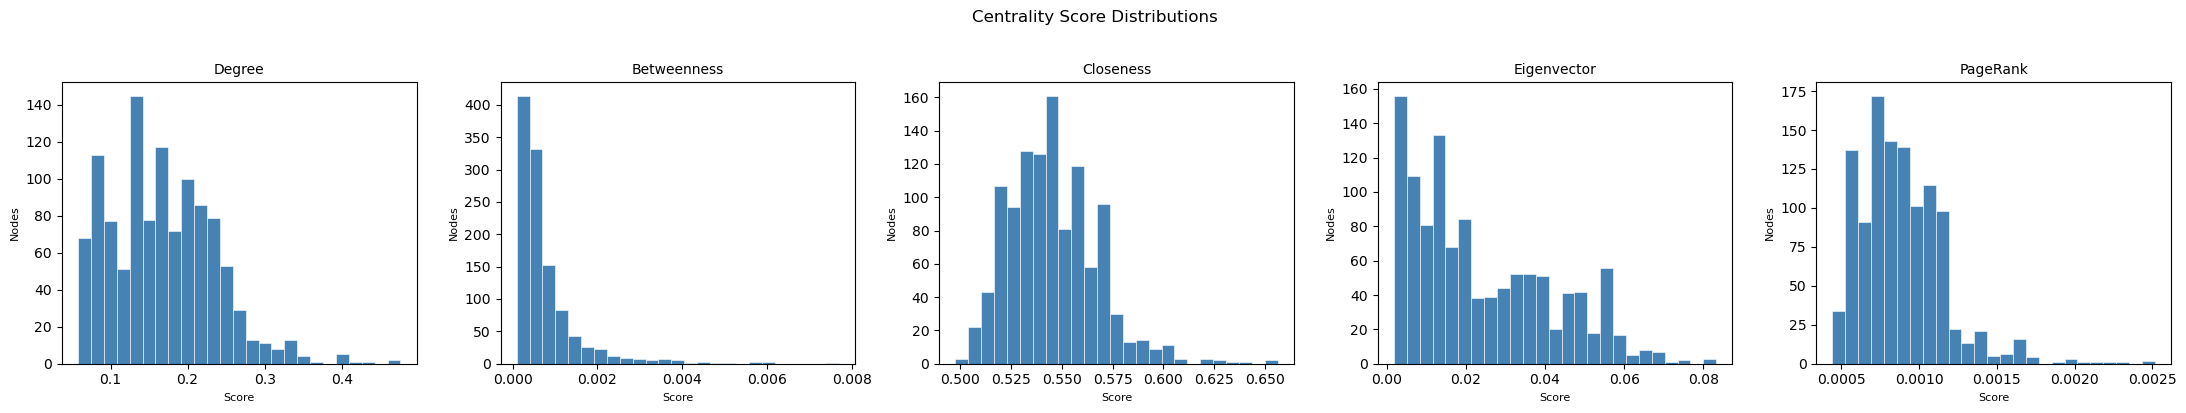

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
measures = [
    (degree_cent,      'Degree'),
    (betweenness_cent, 'Betweenness'),
    (closeness_cent,   'Closeness'),
    (eigenvector_cent, 'Eigenvector'),
    (pagerank,         'PageRank'),
]
for ax, (cent, label) in zip(axes, measures):
    vals = []
    for v in cent.values():
        vals.append(v)
    ax.hist(vals, bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score', fontsize=8)
    ax.set_ylabel('Nodes', fontsize=8)
plt.suptitle('Centrality Score Distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## degree distribution

log-log plot to check for power-law structure.


log-log slope: -0.61 (power-law if -2 to -3)


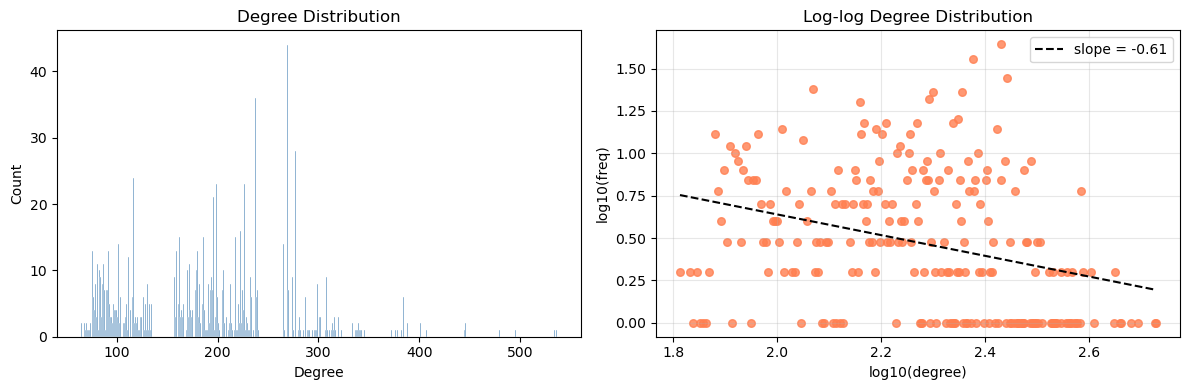

In [ ]:
# checking if degree follows a power law

degree_sequence = []
for nd, d in G_main.degree():
    degree_sequence.append(d)
degree_sequence.sort(reverse=True)

deg_count = Counter(degree_sequence)
deg_vals = sorted(deg_count.keys())

freq_vals = []
for d in deg_vals:
    freq_vals.append(deg_count[d])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(deg_vals, freq_vals, color='steelblue', edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Degree')
ax1.set_ylabel('Count')
ax1.set_title('Degree Distribution')

# filter to nonzero values before taking log
nonzero_d = []
nonzero_f = []
for i in range(len(deg_vals)):
    if deg_vals[i] > 0 and freq_vals[i] > 0:
        nonzero_d.append(deg_vals[i])
        nonzero_f.append(freq_vals[i])

if len(nonzero_d) > 2:
    log_d = []
    for val in nonzero_d:
        log_d.append(np.log10(val))
    log_f = []
    for val in nonzero_f:
        log_f.append(np.log10(val))
    log_d = np.array(log_d)
    log_f = np.array(log_f)
    ax2.scatter(log_d, log_f, color='coral', s=30, alpha=0.8)
    coeffs = np.polyfit(log_d, log_f, 1)
    ax2.plot(log_d, np.poly1d(coeffs)(log_d), 'k--',
             label='slope = ' + str(round(coeffs[0], 2)))
    ax2.legend()
    print("log-log slope:", round(coeffs[0], 2), "(power-law if -2 to -3)")

ax2.set_xlabel('log10(degree)')
ax2.set_ylabel('log10(freq)')
ax2.set_title('Log-log Degree Distribution')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### degree distribution notes

- log-log slope is about **-0.61**, much shallower than a real power-law network (usually -2 to -3)
- histogram is also fairly uniform, no heavy tail like you'd see in a scale-free network
- makes sense for a co-commenter graph: edges come from shared video presence not follows, so most multi-video commenters end up connected to most others (near-clique)
- doesn't affect the community or homophily results, just worth flagging


## network viz

same layout twice, different colours. left coloured by media type, right by time period. comparing the two shows which dimension structures the network more.


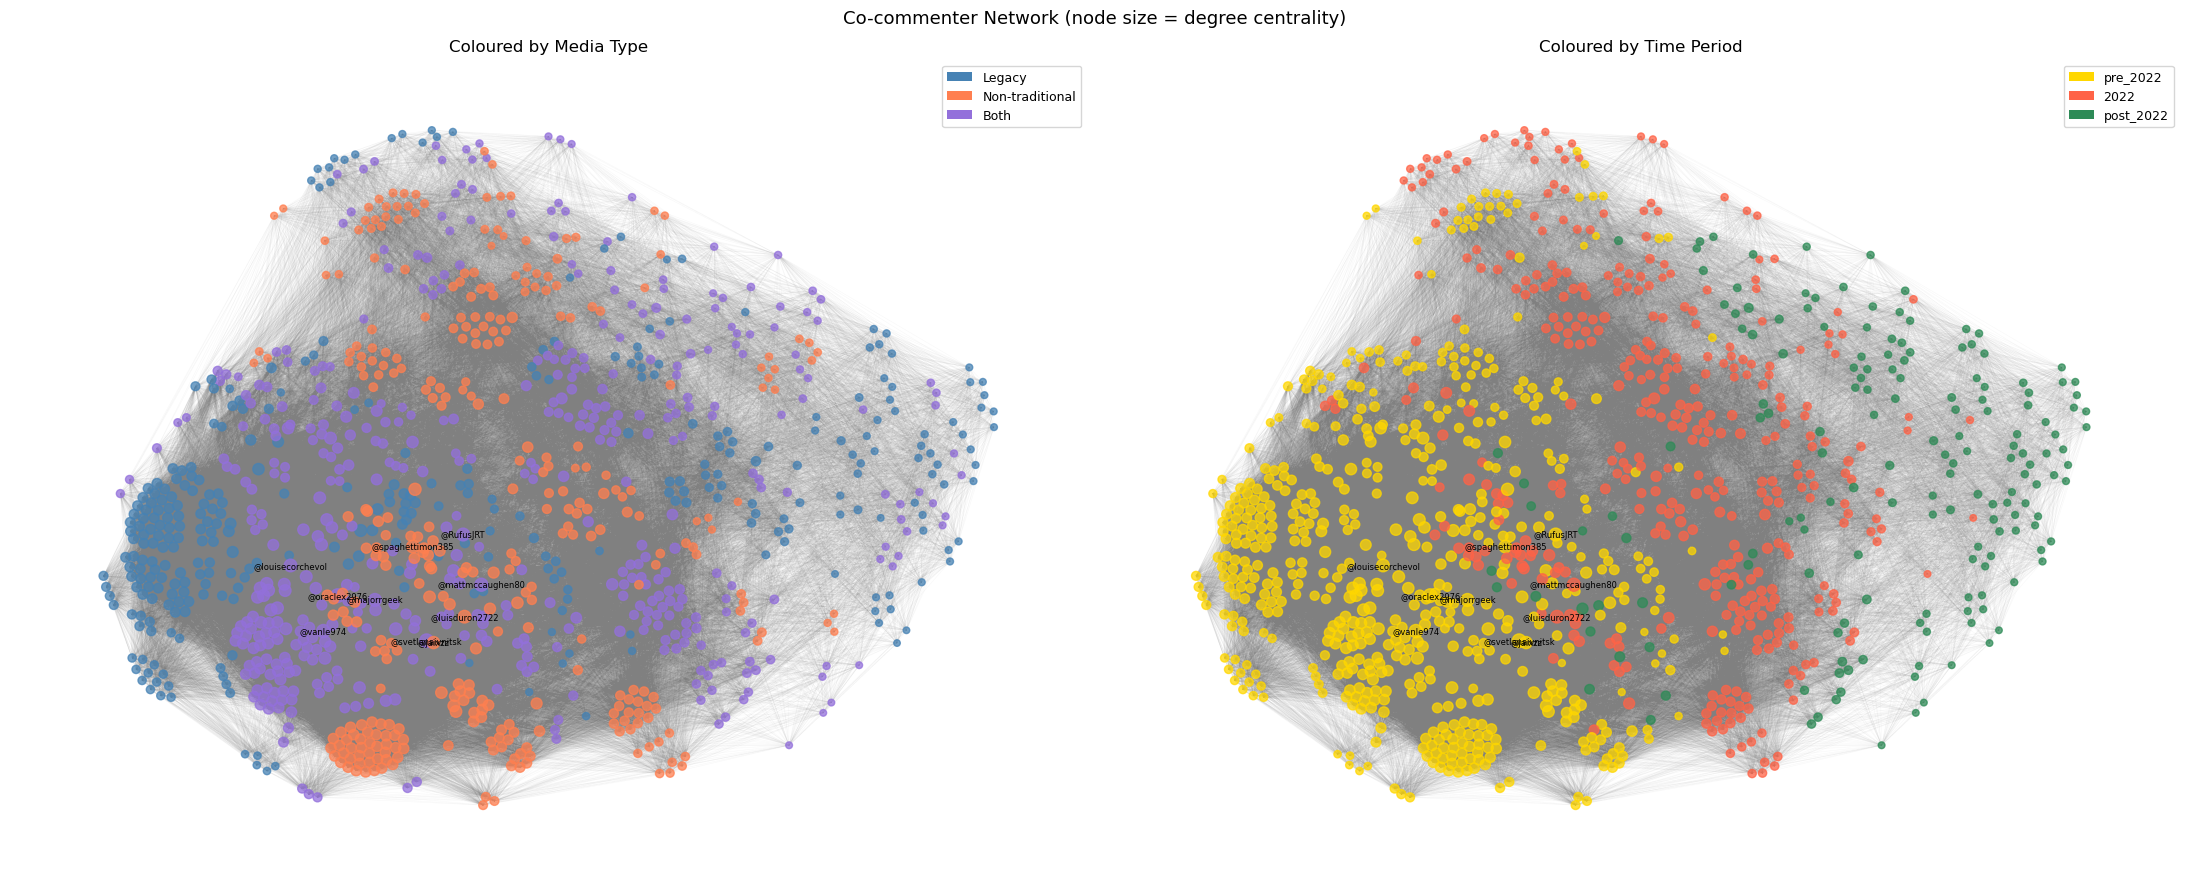

In [ ]:
# two side by side plots on the same layout, different colour schemes

if G_main.number_of_nodes() <= 3000:
    pos = nx.spring_layout(G_main, seed=42, k=0.6)
else:
    pos = nx.kamada_kawai_layout(G_main)

node_sizes = []
for nd in G_main.nodes():
    node_sizes.append(12 + 180 * degree_cent[nd])

# get labels for top 10 nodes by degree
scored = []
for nd, val in degree_cent.items():
    scored.append((val, nd))
scored.sort(reverse=True)
top10_label = {}
for val, nd in scored[:10]:
    top10_label[nd] = nd[:16]

media_col = {'legacy': 'steelblue', 'non_traditional': 'coral', 'both': 'mediumpurple'}
period_col = {'pre_2022': 'gold', '2022': 'tomato', 'post_2022': 'seagreen'}

media_colors = []
for nd in G_main.nodes():
    media_colors.append(media_col.get(G_main.nodes[nd].get('media_type'), 'gray'))

period_colors = []
for nd in G_main.nodes():
    period_colors.append(period_col.get(G_main.nodes[nd].get('time_period'), 'gray'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

nx.draw_networkx_nodes(G_main, pos, ax=ax1, node_color=media_colors,
                       node_size=node_sizes, alpha=0.75)
nx.draw_networkx_edges(G_main, pos, ax=ax1, alpha=0.06, width=0.4, edge_color='gray')
nx.draw_networkx_labels(G_main, pos, labels=top10_label, font_size=6, ax=ax1)
ax1.legend(handles=[
    Patch(facecolor='steelblue',    label='Legacy'),
    Patch(facecolor='coral',        label='Non-traditional'),
    Patch(facecolor='mediumpurple', label='Both'),
], fontsize=9)
ax1.set_title('Coloured by Media Type', fontsize=12)
ax1.axis('off')

nx.draw_networkx_nodes(G_main, pos, ax=ax2, node_color=period_colors,
                       node_size=node_sizes, alpha=0.75)
nx.draw_networkx_edges(G_main, pos, ax=ax2, alpha=0.06, width=0.4, edge_color='gray')
nx.draw_networkx_labels(G_main, pos, labels=top10_label, font_size=6, ax=ax2)
ax2.legend(handles=[
    Patch(facecolor='gold',     label='pre_2022'),
    Patch(facecolor='tomato',   label='2022'),
    Patch(facecolor='seagreen', label='post_2022'),
], fontsize=9)
ax2.set_title('Coloured by Time Period', fontsize=12)
ax2.axis('off')

plt.suptitle('Co-commenter Network (node size = degree centrality)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/network_viz.png', dpi=150, bbox_inches='tight')
plt.show()


## community detection


In [ ]:
random.seed(42)
louvain_partition = community_louvain.best_partition(G_main)
modularity_score = community_louvain.modularity(louvain_partition, G_main)
n_communities = max(louvain_partition.values()) + 1
nx.set_node_attributes(G_main, louvain_partition, 'community')

comm_sizes = Counter(louvain_partition.values())
print("louvain communities:", n_communities, "  Q =", round(modularity_score, 4))

size_list = []
for cid, size in comm_sizes.items():
    size_list.append((size, cid))
size_list.sort(reverse=True)
for size, cid in size_list:
    print("  community", cid, ":", size, "members")

# also try CPM just to compare
k = 3
cpm_communities = list(nx.algorithms.community.k_clique_communities(G_main, k))
if not cpm_communities:
    k = 2
    cpm_communities = list(nx.algorithms.community.k_clique_communities(G_main, k))
# CPM returning 1 community is expected here, not a bug
# co-commenter graphs are very dense -- almost every triplet of users shares a video
# so all k=3 cliques overlap and merge into one giant community
# CPM works better on sparse networks, louvain is more appropriate for this data
print("CPM k=" + str(k) + ":", len(cpm_communities), "communities")


louvain communities: 5   Q = 0.3845
  community 1 : 270 members
  community 2 : 251 members
  community 0 : 249 members
  community 4 : 223 members
  community 3 : 134 members
CPM k=3: 1 communities


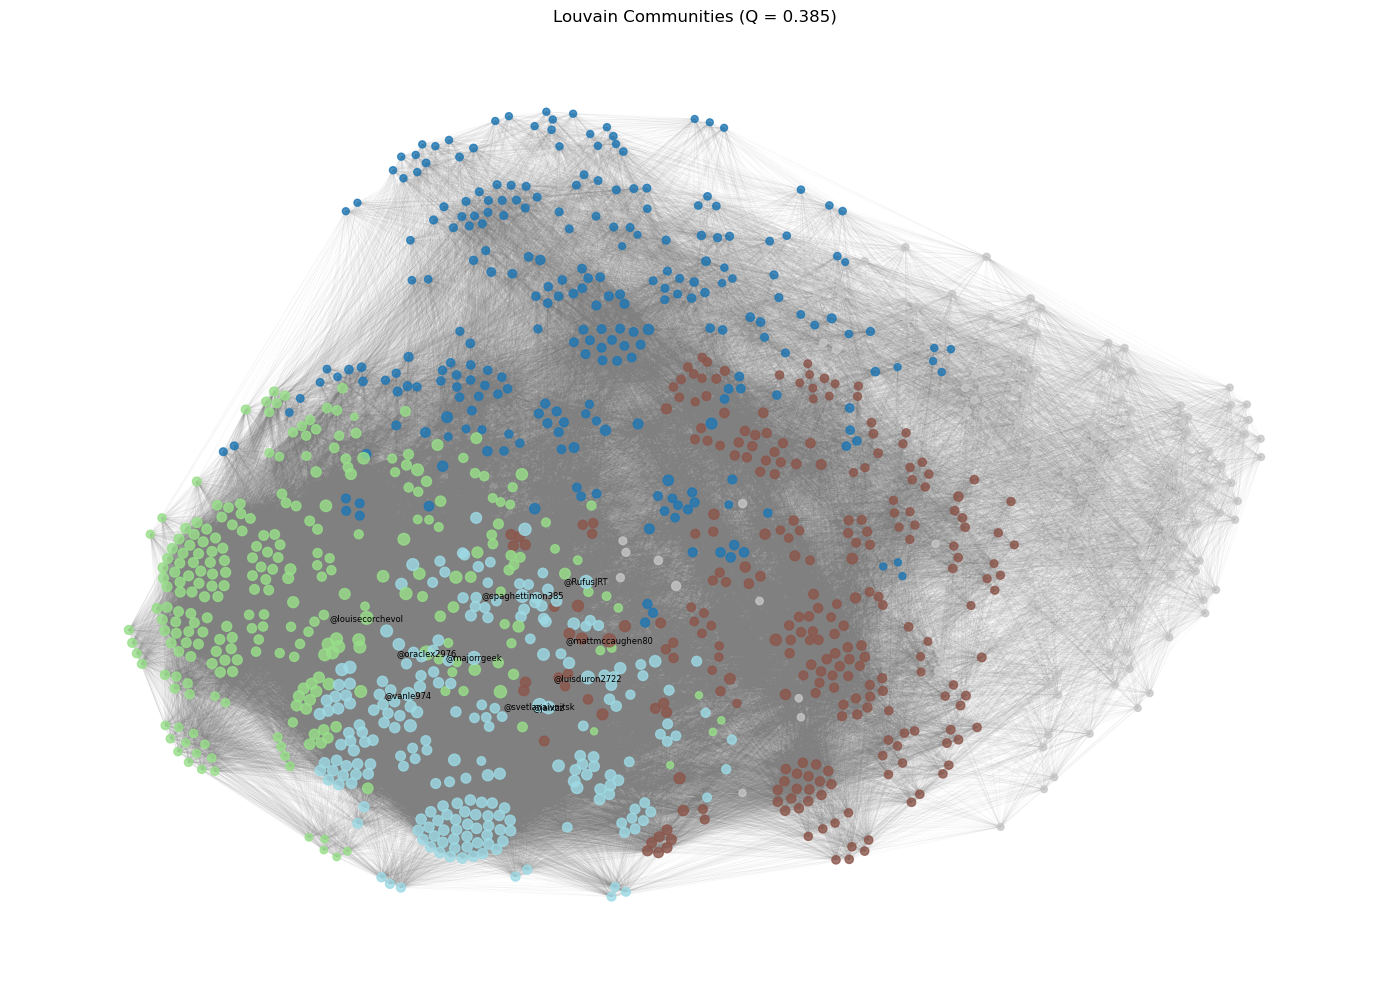

saved GraphML


In [ ]:
cmap_comm = plt.cm.get_cmap('tab20', n_communities)
comm_color_map = {}
i = 0
for cid in sorted(comm_sizes.keys()):
    comm_color_map[cid] = cmap_comm(i)
    i += 1

node_colors_comm = []
for nd in G_main.nodes():
    node_colors_comm.append(comm_color_map[louvain_partition[nd]])

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_main, pos, ax=ax, node_color=node_colors_comm,
                       node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G_main, pos, ax=ax, alpha=0.07, width=0.4, edge_color='gray')
nx.draw_networkx_labels(G_main, pos, labels=top10_label, font_size=6, ax=ax)
ax.set_title('Louvain Communities (Q = ' + str(round(modularity_score, 3)) + ')', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('figures/network_communities.png', dpi=150, bbox_inches='tight')
plt.show()

# export for gephi, need to convert some attributes to basic types first
G_export = G_main.copy()
for nd in G_export.nodes():
    attrs = G_export.nodes[nd]
    attrs['community']     = int(attrs.get('community', -1))
    attrs['avg_likes']     = float(attrs.get('avg_likes', 0.0))
    attrs['avg_sentiment'] = float(attrs.get('avg_sentiment', 0.0))
    attrs['video_count']   = int(attrs.get('video_count', 0))
    attrs['degree_cent']   = float(degree_cent.get(nd, 0.0))
    attrs['pagerank']      = float(pagerank.get(nd, 0.0))
nx.write_graphml(G_export, 'figures/co_commenter_network.graphml')
print("saved GraphML")


## community profiling

break down each louvain community by media type and time period to see what's actually driving the cluster structure.


           size  pct_legacy  pct_nontrad  pct_both  pct_pre2022  pct_2022  pct_post2022  avg_sent  avg_likes
community                                                                                                   
1           270       0.656        0.000     0.344        0.944     0.037         0.019    -0.252      2.308
2           251       0.239        0.251     0.510        0.127     0.785         0.088    -0.335      1.047
0           249       0.096        0.514     0.390        0.394     0.538         0.068    -0.120      2.697
4           223       0.000        0.552     0.448        0.812     0.143         0.045    -0.206      1.873
3           134       0.522        0.142     0.336        0.052     0.097         0.851    -0.373      2.697


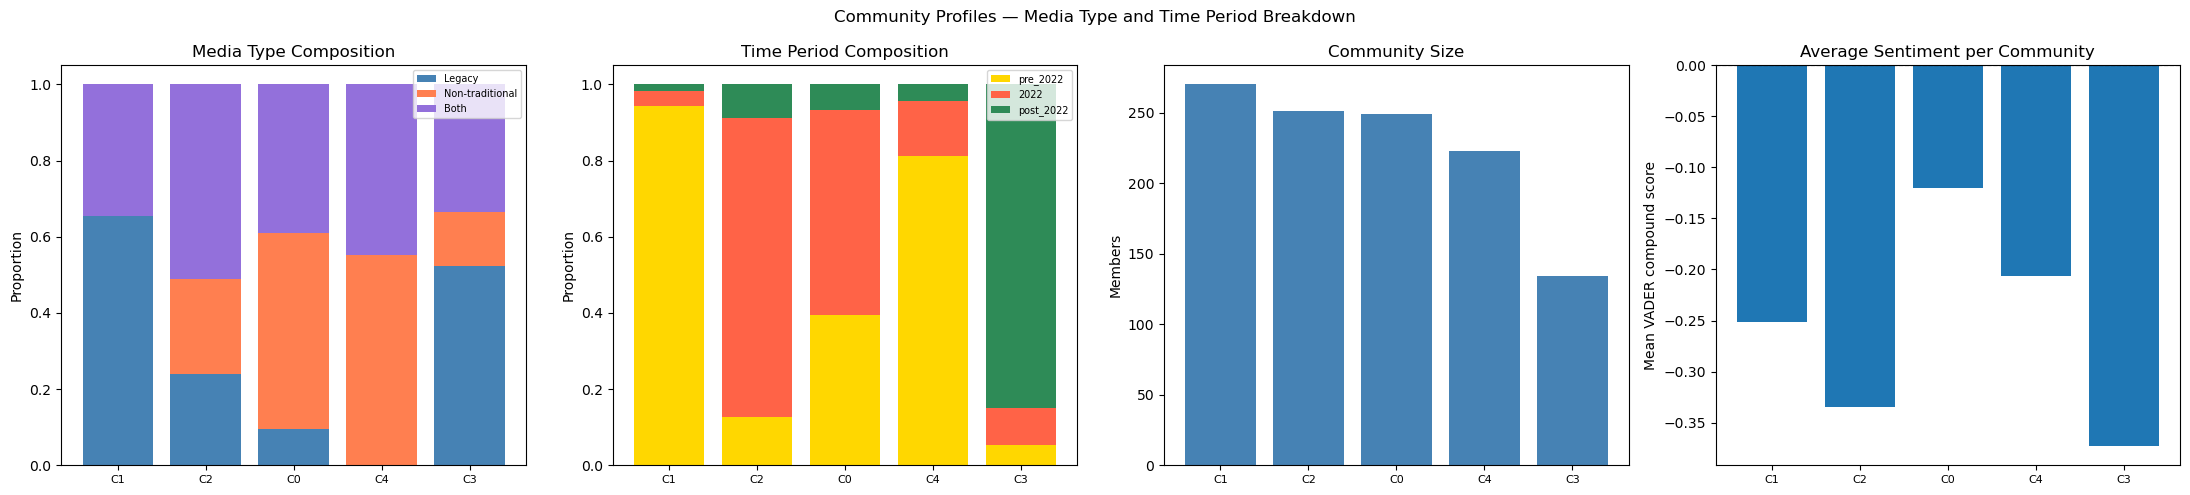

In [ ]:
# profile each community on both dimensions

sent_num = {'positive': 1, 'neutral': 0, 'negative': -1}
profiles = []

for cid in range(n_communities):
    members = []
    for nd, c in louvain_partition.items():
        if c == cid:
            members.append(nd)
    if not members:
        continue
    total = len(members)

    temp_media = []
    for nd in members:
        temp_media.append(G_main.nodes[nd].get('media_type'))
    media_count = Counter(temp_media)

    temp_period = []
    for nd in members:
        temp_period.append(G_main.nodes[nd].get('time_period'))
    period_count = Counter(temp_period)

    sent_total = 0
    for nd in members:
        sent_total += sent_num.get(G_main.nodes[nd].get('sentiment', 'neutral'), 0)

    likes_total = 0.0
    for nd in members:
        likes_total += G_main.nodes[nd].get('avg_likes', 0.0)

    profiles.append({
        'community':    cid,
        'size':         total,
        'pct_legacy':   media_count.get('legacy', 0) / total,
        'pct_nontrad':  media_count.get('non_traditional', 0) / total,
        'pct_both':     media_count.get('both', 0) / total,
        'pct_pre2022':  period_count.get('pre_2022', 0) / total,
        'pct_2022':     period_count.get('2022', 0) / total,
        'pct_post2022': period_count.get('post_2022', 0) / total,
        'avg_sent':     sent_total / total,
        'avg_likes':    likes_total / total,
    })

profile_df = pd.DataFrame(profiles).set_index('community').sort_values('size', ascending=False)
pd.set_option('display.float_format', '{:.3f}'.format)
print(profile_df.to_string())

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

comm_labels = []
for i in profile_df.index:
    comm_labels.append('C' + str(i))
x = np.arange(len(comm_labels))

axes[0].bar(x, profile_df['pct_legacy'],  color='steelblue',    label='Legacy')
axes[0].bar(x, profile_df['pct_nontrad'], color='coral',
            bottom=profile_df['pct_legacy'], label='Non-traditional')
axes[0].bar(x, profile_df['pct_both'],    color='mediumpurple',
            bottom=profile_df['pct_legacy'] + profile_df['pct_nontrad'], label='Both')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comm_labels, fontsize=8)
axes[0].set_title('Media Type Composition')
axes[0].set_ylabel('Proportion')
axes[0].legend(fontsize=7)

axes[1].bar(x, profile_df['pct_pre2022'], color='gold',    label='pre_2022')
axes[1].bar(x, profile_df['pct_2022'],    color='tomato',
            bottom=profile_df['pct_pre2022'], label='2022')
axes[1].bar(x, profile_df['pct_post2022'], color='seagreen',
            bottom=profile_df['pct_pre2022'] + profile_df['pct_2022'], label='post_2022')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comm_labels, fontsize=8)
axes[1].set_title('Time Period Composition')
axes[1].set_ylabel('Proportion')
axes[1].legend(fontsize=7)

axes[2].bar(x, profile_df['size'], color='steelblue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(comm_labels, fontsize=8)
axes[2].set_title('Community Size')
axes[2].set_ylabel('Members')

avg_sent_vals = list(profile_df['avg_sent'])
axes[3].bar(x, avg_sent_vals)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_xticks(x)
axes[3].set_xticklabels(comm_labels, fontsize=8)
axes[3].set_title('Average Sentiment per Community')
axes[3].set_ylabel('Mean VADER compound score')

plt.suptitle('Community Profiles — Media Type and Time Period Breakdown', fontsize=12)
plt.tight_layout()
plt.savefig('figures/community_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


## diffusion / IC model

directed version of the network (higher-liked commenter points to lower-liked). testing four seed strategies to see which spreads furthest.


In [ ]:
# direction: higher liked commenter influences lower liked one
G_dir = nx.DiGraph()
for nd, attrs in G_main.nodes(data=True):
    G_dir.add_node(nd, **attrs)

for u, v, edata in G_main.edges(data=True):
    lu = G_main.nodes[u].get('avg_likes', 0)
    lv = G_main.nodes[v].get('avg_likes', 0)
    w = edata.get('weight', 1)
    if lu > lv:
        G_dir.add_edge(u, v, weight=w)
    elif lv > lu:
        G_dir.add_edge(v, u, weight=w)
    else:
        # tied likes -- go both ways
        G_dir.add_edge(u, v, weight=w)
        G_dir.add_edge(v, u, weight=w)

# IC function needs integer node ids, so relabel
# tried passing string names directly but the function broke
node_list = list(G_dir.nodes())
node_to_int = {}
for i in range(len(node_list)):
    node_to_int[node_list[i]] = i
G_int = nx.relabel_nodes(G_dir, node_to_int)
print("directed graph:", G_int.number_of_nodes(), "nodes,", G_int.number_of_edges(), "edges")

def independentCascade(graph, trialNum, lSeed, activationProb):
    lAvgActivationsPerNode = [0] * nx.number_of_nodes(graph)
    lAvgActivationsPerIteration = []
    for _ in range(trialNum):
        setActive = set(lSeed)
        setLastActive = set(lSeed)
        setNewActive = set()
        while setLastActive:
            for curr in setLastActive:
                for neighbour in graph.neighbors(curr):
                    if neighbour not in setActive and neighbour not in setNewActive:
                        if random.random() < activationProb:
                            setNewActive.add(neighbour)
            setLastActive = setNewActive
            setActive.update(setNewActive)
            setNewActive = set()
        for x in setActive:
            lAvgActivationsPerNode[x] += 1
        lAvgActivationsPerIteration.append(len(setActive))
    avg_per_node = []
    for c in lAvgActivationsPerNode:
        avg_per_node.append(float(c) / trialNum)
    return avg_per_node, lAvgActivationsPerIteration


directed graph: 1127 nodes, 138502 edges


Degree: avg reach = 585.9 / 1127 (52.0%)
PageRank: avg reach = 585.4 / 1127 (51.9%)
Betweenness: avg reach = 889.7 / 1127 (78.9%)
Random: avg reach = 804.6 / 1127 (71.4%)


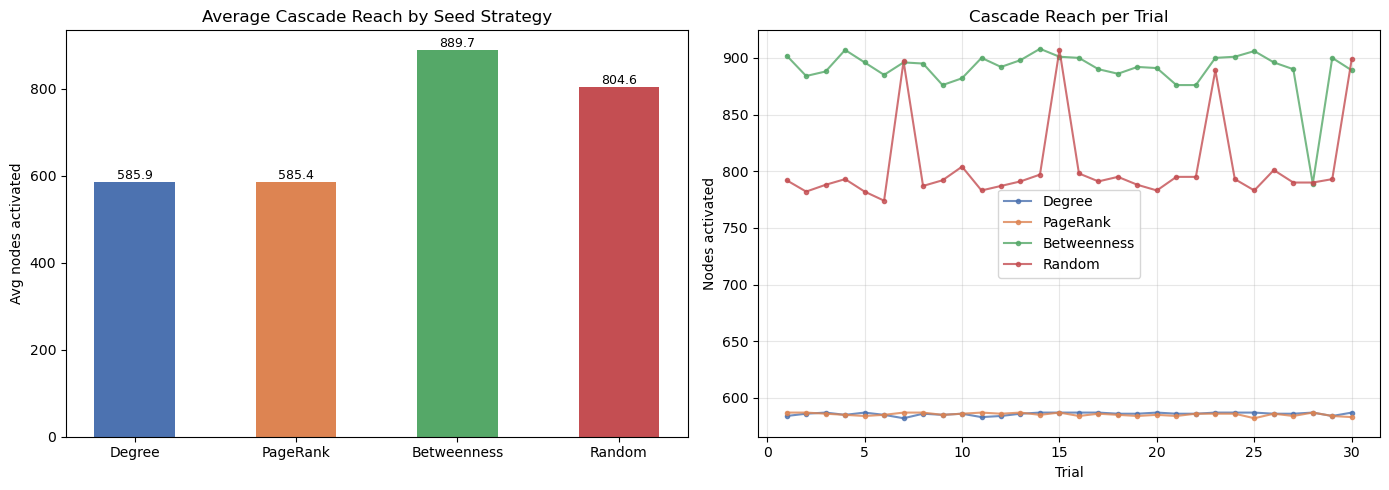

In [ ]:
# compare four seed strategies to see which spreads furthest

ACTIVATION_PROB = 0.1
TRIAL_NUM = 30
K_SEEDS = 5
random.seed(42)

deg_int = nx.degree_centrality(G_int)
pr_int = nx.pagerank(G_int, alpha=0.85)
btw_int = nx.betweenness_centrality(G_int, normalized=True)

def top_k_seeds(cent, k):
    scored = []
    for nd, val in cent.items():
        scored.append((val, nd))
    scored.sort(reverse=True)
    seeds = []
    for val, nd in scored[:k]:
        seeds.append(nd)
    return seeds

strategies = {
    'Degree':      top_k_seeds(deg_int, K_SEEDS),
    'PageRank':    top_k_seeds(pr_int,  K_SEEDS),
    'Betweenness': top_k_seeds(btw_int, K_SEEDS),
    'Random':      random.sample(list(G_int.nodes()), K_SEEDS),
}

results = {}
for name, seeds in strategies.items():
    _, per_iter = independentCascade(G_int, TRIAL_NUM, seeds, ACTIVATION_PROB)
    avg_reach = float(np.mean(per_iter))
    pct = avg_reach / G_int.number_of_nodes() * 100
    results[name] = {'per_iter': per_iter, 'avg_reach': avg_reach, 'pct': pct}
    print(name + ": avg reach =", round(avg_reach, 1), "/",
          G_int.number_of_nodes(), "(" + str(round(pct, 1)) + "%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
strat_names = list(results.keys())

avgs = []
for s in strat_names:
    avgs.append(results[s]['avg_reach'])

bars = ax1.bar(strat_names, avgs, color=colors, width=0.5)
for bar, val in zip(bars, avgs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             str(round(val, 1)), ha='center', va='bottom', fontsize=9)
ax1.set_title('Average Cascade Reach by Seed Strategy')
ax1.set_ylabel('Avg nodes activated')

for s, col in zip(strat_names, colors):
    iters = results[s]['per_iter']
    ax2.plot(range(1, len(iters)+1), iters, 'o-', color=col, label=s, markersize=3, alpha=0.8)
ax2.set_title('Cascade Reach per Trial')
ax2.set_xlabel('Trial')
ax2.set_ylabel('Nodes activated')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/information_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()


### diffusion results

- betweenness seeds reached about 79% of nodes, way better than the other strategies
- degree and pagerank both landed around 52%, even though they pick the most popular/prestigious nodes
- random seeding actually beat degree and pagerank too, probably because the network is so dense that short paths exist everywhere
- betweenness works best here because bridge users connect the legacy and non-traditional sides, so seeding there spreads across both communities


## homophily

assortativity r: positive means similar nodes connect more than random mixing would predict, ~0 means basically random. computing separately for media_type and time_period.
mixing matrices show row-normalised connection probabilities across categories.


media type assortativity:  0.2234
time period assortativity: 0.4419
sentiment assortativity:   0.0024
degree assortativity:      0.3688


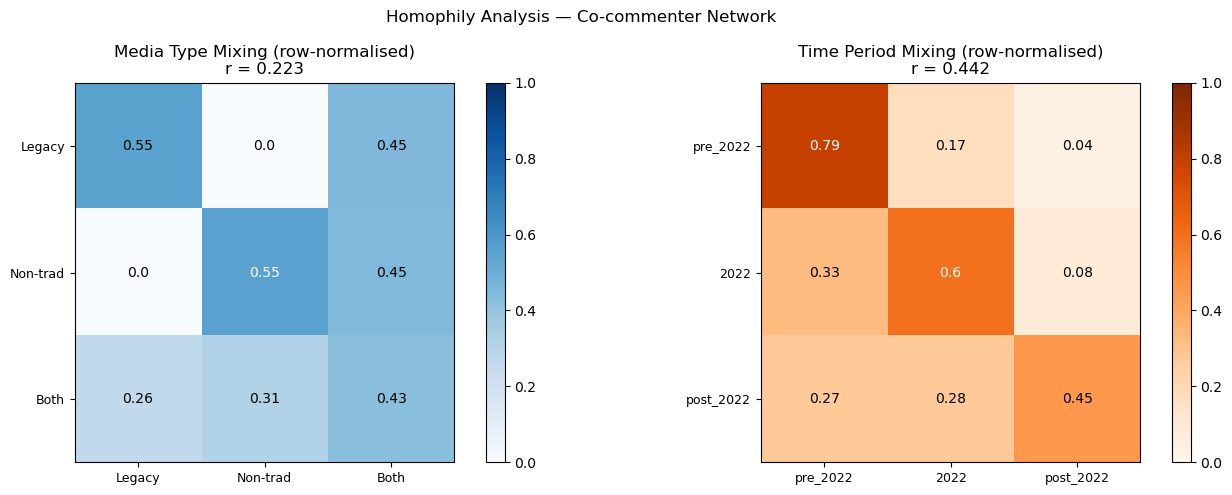

In [ ]:
# assortativity tells us if similar nodes tend to connect

media_assort = nx.attribute_assortativity_coefficient(G_main, 'media_type')
period_assort = nx.attribute_assortativity_coefficient(G_main, 'time_period')
sent_assort = nx.attribute_assortativity_coefficient(G_main, 'sentiment')
deg_assort = nx.degree_assortativity_coefficient(G_main)

print("media type assortativity:", round(media_assort, 4))
print("time period assortativity:", round(period_assort, 4))
print("sentiment assortativity:", round(sent_assort, 4))
print("degree assortativity:", round(deg_assort, 4))

def build_mixing_matrix(G, attr, categories):
    idx = {}
    for i in range(len(categories)):
        idx[categories[i]] = i
    M = np.zeros((len(categories), len(categories)))
    for u, v in G.edges():
        cu = idx.get(G.nodes[u].get(attr))
        cv = idx.get(G.nodes[v].get(attr))
        if cu is not None and cv is not None:
            M[cu][cv] += 1
            M[cv][cu] += 1
    for row_i in range(len(categories)):
        row_sum = M[row_i].sum()
        if row_sum > 0:
            M[row_i] = M[row_i] / row_sum
    return M

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

media_cats = ['legacy', 'non_traditional', 'both']
media_names = ['Legacy', 'Non-trad', 'Both']
M_media = build_mixing_matrix(G_main, 'media_type', media_cats)
im1 = ax1.imshow(M_media, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(3))
ax1.set_xticklabels(media_names, fontsize=9)
ax1.set_yticks(range(3))
ax1.set_yticklabels(media_names, fontsize=9)
for i in range(3):
    for j in range(3):
        color = 'white' if M_media[i, j] > 0.55 else 'black'
        ax1.text(j, i, str(round(M_media[i, j], 2)), ha='center', va='center',
                 color=color, fontsize=10)
ax1.set_title('Media Type Mixing (row-normalised)\nr = ' + str(round(media_assort, 3)))
plt.colorbar(im1, ax=ax1)

period_cats = ['pre_2022', '2022', 'post_2022']
period_names = ['pre_2022', '2022', 'post_2022']
M_period = build_mixing_matrix(G_main, 'time_period', period_cats)
im2 = ax2.imshow(M_period, cmap='Oranges', vmin=0, vmax=1)
ax2.set_xticks(range(3))
ax2.set_xticklabels(period_names, fontsize=9)
ax2.set_yticks(range(3))
ax2.set_yticklabels(period_names, fontsize=9)
for i in range(3):
    for j in range(3):
        color = 'white' if M_period[i, j] > 0.55 else 'black'
        ax2.text(j, i, str(round(M_period[i, j], 2)), ha='center', va='center',
                 color=color, fontsize=10)
ax2.set_title('Time Period Mixing (row-normalised)\nr = ' + str(round(period_assort, 3)))
plt.colorbar(im2, ax=ax2)

plt.suptitle('Homophily Analysis — Co-commenter Network', fontsize=12)
plt.tight_layout()
plt.savefig('figures/homophily_mixing.png', dpi=150, bbox_inches='tight')
plt.show()


mean VADER sentiment by media type:
  legacy : -0.1446 (n=331)
  non_traditional : -0.0964 (n=333)
  both : -0.1121 (n=463)

mean VADER sentiment by time period:
  pre_2022 : -0.0916 (n=573)
  2022 : -0.1322 (n=386)
  post_2022 : -0.169 (n=168)


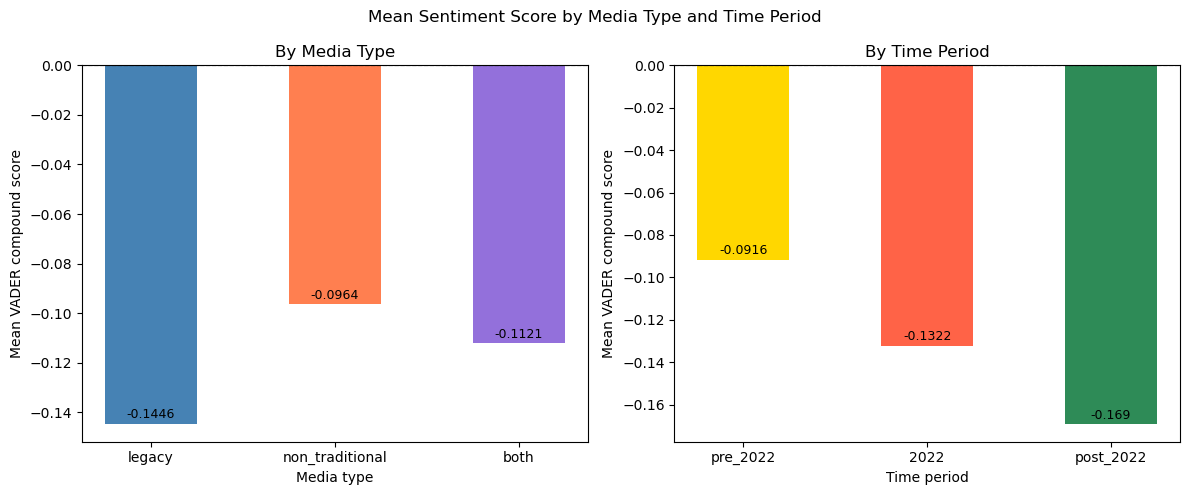

In [14]:
# group nodes by media type and average their sentiment scores

media_sent_total = {}
media_sent_count = {}
for nd, attrs in G_main.nodes(data=True):
    mtype = attrs.get('media_type', 'unknown')
    score = attrs.get('avg_sentiment', 0.0)
    if mtype not in media_sent_total:
        media_sent_total[mtype] = 0.0
        media_sent_count[mtype] = 0
    media_sent_total[mtype] += score
    media_sent_count[mtype] += 1

media_means = {}
for mtype in media_sent_total:
    media_means[mtype] = media_sent_total[mtype] / media_sent_count[mtype]

print("mean VADER sentiment by media type:")
for mtype in ['legacy', 'non_traditional', 'both']:
    if mtype in media_means:
        print(" ", mtype, ":", round(media_means[mtype], 4),
              "(n=" + str(media_sent_count[mtype]) + ")")

# same thing but grouped by time period
period_sent_total = {}
period_sent_count = {}
for nd, attrs in G_main.nodes(data=True):
    period = attrs.get('time_period', 'unknown')
    score = attrs.get('avg_sentiment', 0.0)
    if period not in period_sent_total:
        period_sent_total[period] = 0.0
        period_sent_count[period] = 0
    period_sent_total[period] += score
    period_sent_count[period] += 1

period_means = {}
for period in period_sent_total:
    period_means[period] = period_sent_total[period] / period_sent_count[period]

print()
print("mean VADER sentiment by time period:")
for period in ['pre_2022', '2022', 'post_2022']:
    if period in period_means:
        print(" ", period, ":", round(period_means[period], 4),
              "(n=" + str(period_sent_count[period]) + ")")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

media_labels = ['legacy', 'non_traditional', 'both']
media_vals = []
for m in media_labels:
    media_vals.append(media_means.get(m, 0.0))

media_colors = ['steelblue', 'coral', 'mediumpurple']
bars1 = ax1.bar(media_labels, media_vals, color=media_colors, width=0.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars1, media_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             str(round(val, 4)), ha='center', va='bottom', fontsize=9)
ax1.set_title('By Media Type')
ax1.set_ylabel('Mean VADER compound score')
ax1.set_xlabel('Media type')

period_labels = ['pre_2022', '2022', 'post_2022']
period_vals = []
for p in period_labels:
    period_vals.append(period_means.get(p, 0.0))

period_colors = ['gold', 'tomato', 'seagreen']
bars2 = ax2.bar(period_labels, period_vals, color=period_colors, width=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, period_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             str(round(val, 4)), ha='center', va='bottom', fontsize=9)
ax2.set_title('By Time Period')
ax2.set_ylabel('Mean VADER compound score')
ax2.set_xlabel('Time period')

plt.suptitle('Mean Sentiment Score by Media Type and Time Period', fontsize=12)
plt.tight_layout()
plt.savefig('figures/sentiment_by_group.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# stats tests to check if sentiment differences are real or just noise
from scipy import stats

legacy_scores = []
nontrad_scores = []
pre2022_scores = []
scores_2022 = []
post2022_scores = []

for nd, attrs in G_main.nodes(data=True):
    score = attrs.get('avg_sentiment', 0.0)
    mtype = attrs.get('media_type', '')
    period = attrs.get('time_period', '')
    if mtype == 'legacy':
        legacy_scores.append(score)
    elif mtype == 'non_traditional':
        nontrad_scores.append(score)
    if period == 'pre_2022':
        pre2022_scores.append(score)
    elif period == '2022':
        scores_2022.append(score)
    elif period == 'post_2022':
        post2022_scores.append(score)

print("group sizes:")
print("  legacy:", len(legacy_scores))
print("  non_traditional:", len(nontrad_scores))
print("  pre_2022:", len(pre2022_scores))
print("  2022:", len(scores_2022))
print("  post_2022:", len(post2022_scores))
print()

# Mann-Whitney U: legacy vs non_traditional
# non-parametric, doesnt assume normal distribution
u_stat, u_pval = stats.mannwhitneyu(legacy_scores, nontrad_scores, alternative='two-sided')
print("Mann-Whitney U test: legacy vs non-traditional sentiment")
print("  U statistic:", round(u_stat, 2))
print("  p-value:", round(u_pval, 6))
if u_pval < 0.05:
    print("  -> p < 0.05: the sentiment difference between groups is statistically significant")
    print("     (unlikely to be random noise)")
else:
    print("  -> p >= 0.05: no statistically significant sentiment difference between groups")
print()

# Kruskal-Wallis: across three time periods
# basically a non-parametric version of one-way ANOVA
h_stat, h_pval = stats.kruskal(pre2022_scores, scores_2022, post2022_scores)
print("Kruskal-Wallis test: sentiment across pre_2022 / 2022 / post_2022")
print("  H statistic:", round(h_stat, 2))
print("  p-value:", round(h_pval, 6))
if h_pval < 0.05:
    print("  -> p < 0.05: at least one time period has significantly different sentiment")
    print("     (the conflict timeline is associated with shifts in comment tone)")
else:
    print("  -> p >= 0.05: no statistically significant sentiment shift across time periods")


group sizes:
  legacy: 331
  non_traditional: 333
  pre_2022: 573
  2022: 386
  post_2022: 168

Mann-Whitney U test: legacy vs non-traditional sentiment
  U statistic: 50437.0
  p-value: 0.058564
  -> p >= 0.05: no statistically significant sentiment difference between groups

Kruskal-Wallis test: sentiment across pre_2022 / 2022 / post_2022
  H statistic: 5.76
  p-value: 0.056236
  -> p >= 0.05: no statistically significant sentiment shift across time periods


## summary


legacy texts: 16742
non-traditional texts: 14220

top 8 words per topic -- LEGACY:
  topic 1 : news, bbc, god, propaganda, people, media, russian, truth
  topic 2 : russia, ukraine, nato, russian, troops, military, west, country
  topic 3 : like, just, world, let, long, states, did, united
  topic 4 : biden, russia, putin, china, ukraine, trump, president, needs
  topic 5 : war, putin, people, world, nuclear, don, want, peace

top 8 words per topic -- NON-TRADITIONAL:
  topic 1 : russia, ukraine, nato, west, war, eu, country, nuclear
  topic 2 : people, war, putin, years, russians, did, just, say
  topic 3 : russian, ukrainian, ukraine, russians, crimea, army, military, ukrainians
  topic 4 : putin, russia, trump, war, world, ukraine, china, peace
  topic 5 : like, video, just, really, propaganda, good, know, don


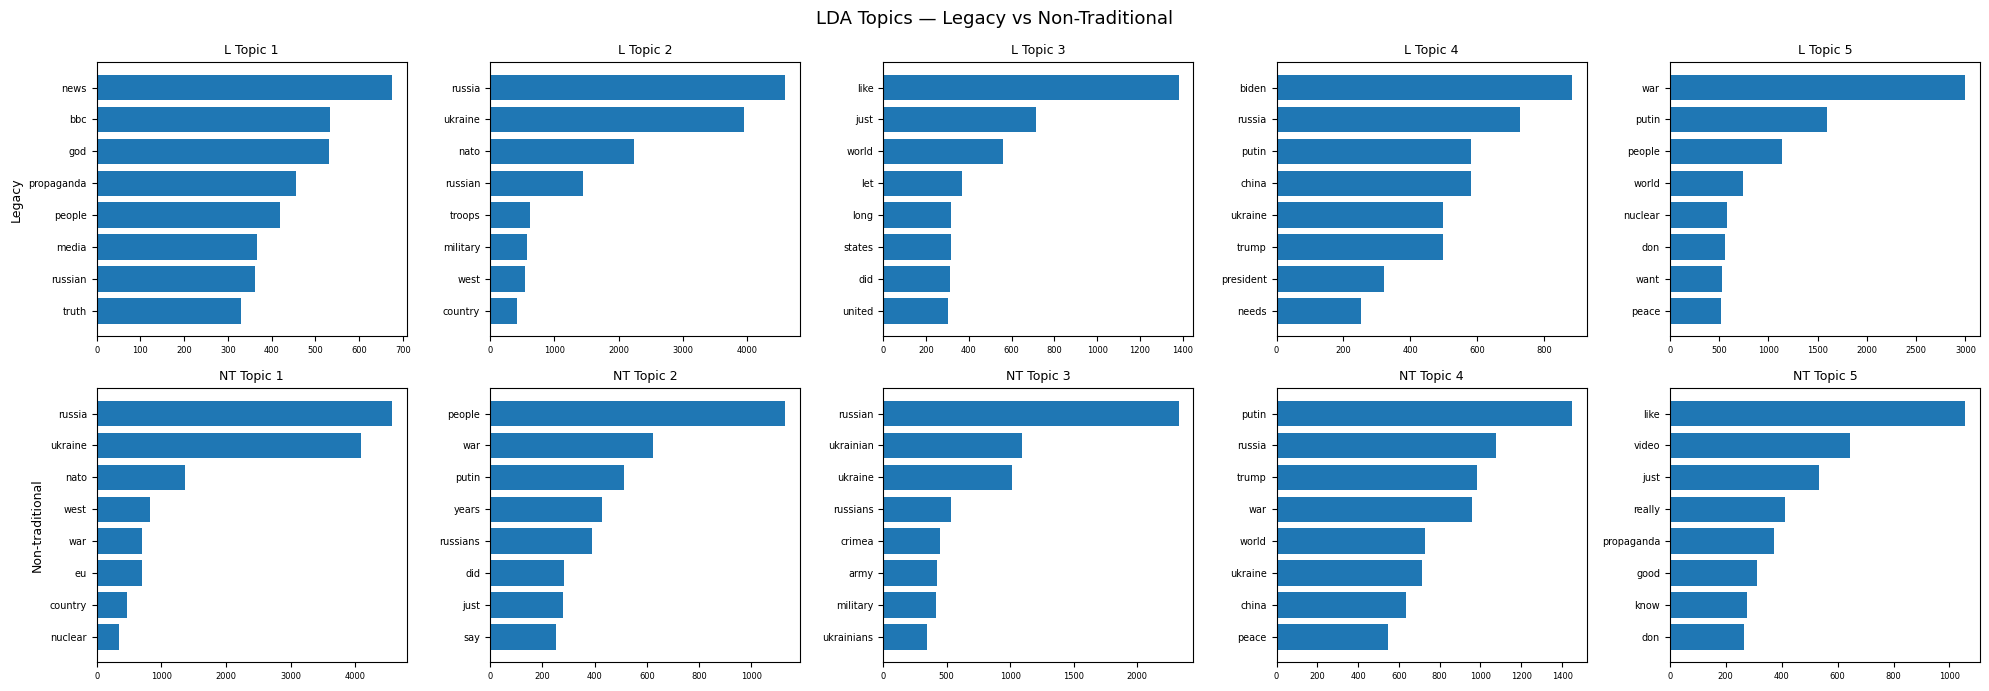

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# split texts by media type
legacy_texts = []
nontrad_texts = []

for row in all_rows:
    if row['media_type'] == 'legacy':
        legacy_texts.append(row['text'])
    elif row['media_type'] == 'non_traditional':
        nontrad_texts.append(row['text'])

print("legacy texts:", len(legacy_texts))
print("non-traditional texts:", len(nontrad_texts))

N_TOPICS = 5
N_TOP_WORDS = 8

# fit lda separately for each group
vectorizer_leg = CountVectorizer(max_features=500, min_df=3, stop_words='english')
dtm_leg = vectorizer_leg.fit_transform(legacy_texts)
vocab_leg = vectorizer_leg.get_feature_names_out()

lda_leg = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
lda_leg.fit(dtm_leg)

vectorizer_nt = CountVectorizer(max_features=500, min_df=3, stop_words='english')
dtm_nt = vectorizer_nt.fit_transform(nontrad_texts)
vocab_nt = vectorizer_nt.get_feature_names_out()

lda_nt = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
lda_nt.fit(dtm_nt)

print()
print("top", N_TOP_WORDS, "words per topic -- LEGACY:")
for topic_idx in range(N_TOPICS):
    top_indices = lda_leg.components_[topic_idx].argsort()[::-1][:N_TOP_WORDS]
    top_words = []
    for idx in top_indices:
        top_words.append(vocab_leg[idx])
    print("  topic", topic_idx + 1, ":", ', '.join(top_words))

print()
print("top", N_TOP_WORDS, "words per topic -- NON-TRADITIONAL:")
for topic_idx in range(N_TOPICS):
    top_indices = lda_nt.components_[topic_idx].argsort()[::-1][:N_TOP_WORDS]
    top_words = []
    for idx in top_indices:
        top_words.append(vocab_nt[idx])
    print("  topic", topic_idx + 1, ":", ', '.join(top_words))

# chart -- 2 rows (legacy top, non-trad bottom), 5 cols (one per topic)
fig, axes = plt.subplots(2, N_TOPICS, figsize=(20, 7))

for topic_idx in range(N_TOPICS):
    top_indices = lda_leg.components_[topic_idx].argsort()[::-1][:N_TOP_WORDS]
    words = []
    weights = []
    for idx in top_indices:
        words.append(vocab_leg[idx])
        weights.append(lda_leg.components_[topic_idx][idx])
    axes[0][topic_idx].barh(range(N_TOP_WORDS), weights[::-1])
    axes[0][topic_idx].set_yticks(range(N_TOP_WORDS))
    axes[0][topic_idx].set_yticklabels(words[::-1], fontsize=7)
    axes[0][topic_idx].set_title('L Topic ' + str(topic_idx + 1), fontsize=9)
    axes[0][topic_idx].tick_params(axis='x', labelsize=6)

    top_indices = lda_nt.components_[topic_idx].argsort()[::-1][:N_TOP_WORDS]
    words = []
    weights = []
    for idx in top_indices:
        words.append(vocab_nt[idx])
        weights.append(lda_nt.components_[topic_idx][idx])
    axes[1][topic_idx].barh(range(N_TOP_WORDS), weights[::-1])
    axes[1][topic_idx].set_yticks(range(N_TOP_WORDS))
    axes[1][topic_idx].set_yticklabels(words[::-1], fontsize=7)
    axes[1][topic_idx].set_title('NT Topic ' + str(topic_idx + 1), fontsize=9)
    axes[1][topic_idx].tick_params(axis='x', labelsize=6)

axes[0][0].set_ylabel('Legacy', fontsize=9)
axes[1][0].set_ylabel('Non-traditional', fontsize=9)

plt.suptitle('LDA Topics — Legacy vs Non-Traditional', fontsize=13)
plt.tight_layout()
plt.savefig('figures/lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()


### lda topic notes

- LDA finds recurring word clusters in comments without being told what to look for
- running it separately on legacy and non-traditional lets us compare what each group was talking about
- different topic distributions suggest different narrative framing, beyond just sentiment scores
- shifts in dominant topics across time periods could show how the discourse changed as the war escalated


In [17]:
print("nodes:", G_main.number_of_nodes(), " edges:", G_main.number_of_edges())
print("density:", round(nx.density(G_main), 5))
print("modularity Q:", round(modularity_score, 4), "  communities:", n_communities)
print()

for label, cent in [('Degree', degree_cent), ('PageRank', pagerank), ('Betweenness', betweenness_cent)]:
    best_node = None
    best_val = -1
    for nd, val in cent.items():
        if val > best_val:
            best_val = val
            best_node = nd
    mtype = G_main.nodes[best_node].get('media_type',  '?')
    period = G_main.nodes[best_node].get('time_period', '?')
    print(label + " top:", best_node, "  media=" + mtype + "  period=" + period)

print()
print("media type assortativity:", round(media_assort, 4))
print("time period assortativity:", round(period_assort, 4))
print("sentiment assortativity:", round(sent_assort, 4))
print("degree assortativity:", round(deg_assort, 4))

print()
best_name = None
best_reach = -1
worst_name = None
worst_reach = float('inf')
for name, res in results.items():
    if res['avg_reach'] > best_reach:
        best_reach = res['avg_reach']
        best_name = name
    if res['avg_reach'] < worst_reach:
        worst_reach = res['avg_reach']
        worst_name = name
print("best seed strategy:", best_name, " avg reach:", round(best_reach, 1))
print("worst seed strategy:", worst_name)


nodes: 1127  edges: 106301
density: 0.16753
modularity Q: 0.3845   communities: 5

Degree top: @oraclex2976   media=both  period=pre_2022
PageRank top: @svetlanaivnitskaya3504   media=both  period=pre_2022
Betweenness top: @RufusJRT   media=both  period=pre_2022

media type assortativity:  0.2234
time period assortativity: 0.4419
sentiment assortativity:   0.0024
degree assortativity:      0.3688

best seed strategy: Betweenness  avg reach: 889.7
worst seed strategy: PageRank
